In [114]:
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
from efficientvit.sam_model_zoo import create_sam_model
from efficientvit.models.efficientvit.sam import EfficientViTSamPredictor
# from efficientvit.models.efficientvit.sam import EfficientViTSamAutomaticMaskGenerator

cfg = {
    'l0': 'assets/checkpoints/sam/l0.pt',
    'l1': 'assets/checkpoints/sam/l1.pt',
    'l2': 'assets/checkpoints/sam/l2.pt',
    'img_path': 'assets/fig/cat.jpg'
}
model_name = 'l2'

efficientvit_sam = create_sam_model(name=model_name, weight_url=cfg[model_name], pretrained=True).eval()
efficientvit_sam.to('cpu')
efficientvit_sam_predictor = EfficientViTSamPredictor(efficientvit_sam)
# efficientvit_mask_generator = EfficientViTSamAutomaticMaskGenerator(efficientvit_sam)

In [115]:
img = plt.imread(cfg['img_path'])
print(img.shape)
point = torch.Tensor([[img.shape[0] // 2, img.shape[1] // 2]])#, [img.shape[0] // 4, img.shape[1] // 4]])
point_coords = torch.Tensor([(x,y) for x, y in point]).view(1, -1, 2).float()
point_labels = torch.ones(point_coords.shape[1]).view(1, -1).long()
print(point_coords.shape, point_labels.shape)
print(point_coords)

(480, 640, 3)
torch.Size([1, 1, 2]) torch.Size([1, 1])
tensor([[[240., 320.]]])


In [118]:
efficientvit_sam_predictor.set_image(img)
masks, _, _ = efficientvit_sam_predictor.predict_torch(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True,
)

torch.Size([1, 3, 480, 640])


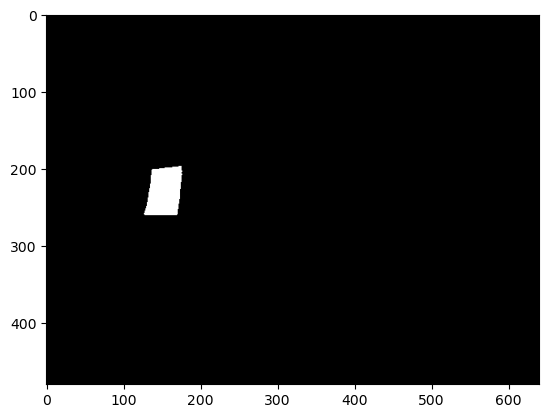

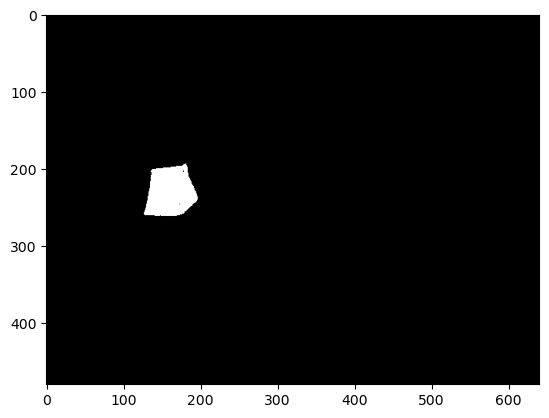

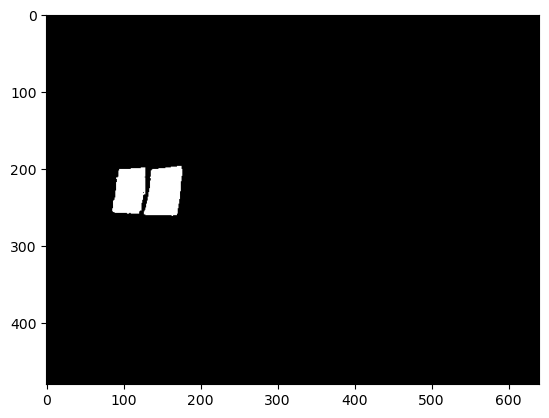

In [120]:
print(masks.shape)
for mask in masks[0, :]:
    plt.figure()
    plt.imshow(mask, cmap='gray')